# 08 — SARIMAX Forecasting v2

**Gold Nexus Alpha — professor-style SARIMAX revision**

This notebook revises SARIMAX to use the same standard as the Naive and revised ARIMA notebooks.

Main corrections:

1. Keep Dataset B and the locked validation/test periods.
2. Exclude `high_yield` from the main model.
3. Use lagged exogenous factors so the model does not depend on same-day factor information.
4. Add deterministic trend/month terms as a professor-style option.
5. Compare static multi-step SARIMAX forecasts as diagnostics.
6. Add one-step rolling SARIMAX forecasts as the primary daily evaluation mode.
7. Select the final SARIMAX candidate by rolling validation RMSE among SARIMAX-family candidates.
8. Export JSON artifacts for the frontend and later model comparison notebook.

Important interpretation:

- Static SARIMAX forecasts can underforecast during a gold breakout.
- Rolling one-step SARIMAX updates with each newly observed gold price and is more comparable to Naive.

In [1]:
# ======================================================================================
# CELL 1 — REPO SYNC AND CLEAN RESET
# ======================================================================================
# Purpose:
# - Clone the GitHub repository into Colab.
# - Load GITHUB_TOKEN from Colab Secrets.
# - Keep the clean Colab → GitHub artifact workflow used across Gold Nexus Alpha.
# ======================================================================================

import os
import shutil
import subprocess
from pathlib import Path
from datetime import datetime, timezone

try:
    from google.colab import userdata
except Exception:
    userdata = None

REPO_OWNER = "rathee000001"
REPO_NAME  = "nyit-gold-intelligence-2026"
BRANCH     = "main"

BASE_DIR = Path("/content")
PROJECT_DIR = BASE_DIR / REPO_NAME

GITHUB_TOKEN = None
if userdata is not None:
    try:
        GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
    except Exception:
        GITHUB_TOKEN = None

if not GITHUB_TOKEN:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")

def run_cmd(cmd, cwd=None, allow_fail=False, display_cmd=None):
    """Run a shell command without printing secrets."""
    shown = display_cmd if display_cmd is not None else cmd
    if isinstance(shown, (list, tuple)):
        shown = " ".join(str(x) for x in shown)
    print(f">> {shown}")
    p = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if p.stdout:
        print(p.stdout)
    if p.stderr:
        print(p.stderr)
    if p.returncode != 0 and not allow_fail:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {shown}")
    return p

# Clean reset.
if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)
    print(f"🧹 Removed existing project folder: {PROJECT_DIR}")

public_url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
auth_url = f"https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git" if GITHUB_TOKEN else public_url

run_cmd(
    ["git", "clone", "--branch", BRANCH, auth_url, str(PROJECT_DIR)],
    display_cmd=["git", "clone", "--branch", BRANCH, f"https://***@github.com/{REPO_OWNER}/{REPO_NAME}.git", str(PROJECT_DIR)]
)

run_cmd(["git", "config", "user.email", "colab-artifact-bot@gold-nexus-alpha.local"], cwd=str(PROJECT_DIR))
run_cmd(["git", "config", "user.name", "Gold Nexus Alpha Colab"], cwd=str(PROJECT_DIR))
run_cmd(["git", "status", "--short"], cwd=str(PROJECT_DIR), allow_fail=True)

print("✅ Repo ready:", PROJECT_DIR)
print("✅ Branch:", BRANCH)
print("✅ UTC time:", datetime.now(timezone.utc).isoformat())

>> git clone --branch main https://***@github.com/rathee000001/nyit-gold-intelligence-2026.git /content/nyit-gold-intelligence-2026
Cloning into '/content/nyit-gold-intelligence-2026'...

>> git config user.email colab-artifact-bot@gold-nexus-alpha.local
>> git config user.name Gold Nexus Alpha Colab
>> git status --short
✅ Repo ready: /content/nyit-gold-intelligence-2026
✅ Branch: main
✅ UTC time: 2026-04-30T22:05:33.953391+00:00


In [2]:
# ======================================================================================
# CELL 2 — DEPENDENCIES
# ======================================================================================
# Purpose:
# - Load SARIMAX/time-series libraries and scaling utilities.
# ======================================================================================

import sys
import json
import math
import glob
import warnings
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    import statsmodels

try:
    import sklearn
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    import sklearn

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics import tsaplots

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 160)

print("✅ Dependencies loaded")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("statsmodels:", statsmodels.__version__)
print("sklearn:", sklearn.__version__)

✅ Dependencies loaded
pandas: 2.2.2
numpy: 2.0.2
statsmodels: 0.14.6
sklearn: 1.6.1


In [3]:
# ======================================================================================
# CELL 3 — PATH SETUP, INPUT DETECTION, AND LOCKED TIME WINDOWS
# ======================================================================================
# Purpose:
# - Locate Dataset B: data/aligned/model_ready_multivariate.csv
# - Lock the official train / validation / test dates.
# - Prepare lagged exogenous variables safely.
# ======================================================================================

PROJECT_DIR = Path(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / "data"
ALIGNED_DIR = DATA_DIR / "aligned"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
MODELS_ARTIFACTS_DIR = ARTIFACTS_DIR / "models"
PAGES_ARTIFACTS_DIR = ARTIFACTS_DIR / "pages"

for folder in [ALIGNED_DIR, MODELS_ARTIFACTS_DIR, PAGES_ARTIFACTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

OFFICIAL_FORECAST_CUTOFF_DATE = "2026-03-31"

CORE_MULTIVARIATE_START = "2006-01-02"
CORE_MULTIVARIATE_END   = OFFICIAL_FORECAST_CUTOFF_DATE

TRAIN_START = "2006-01-02"
TRAIN_END   = "2018-12-31"

VALIDATION_START = "2019-01-01"
VALIDATION_END   = "2022-12-30"

TEST_START = "2023-01-02"
TEST_END   = "2026-03-31"

TARGET_COL = "gold_price"

# Locked SARIMAX exogenous variables from project plan.
BASE_EXOGENOUS_FACTORS = [
    "real_yield",
    "usd_index",
    "vix_index",
    "gpr_index",
    "policy_unc",
    "gld_tonnes",
    "oil_wti",
]

EXCLUDED_FROM_MAIN_MODEL = ["high_yield"]

SARIMAX_CANDIDATE_ORDERS = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
]

MAX_STATIC_CANDIDATES_TO_ROLL = 3
ROLLING_REFIT_ON_APPEND_FAILURE = True

candidate_inputs = [
    ALIGNED_DIR / "model_ready_multivariate.csv",
    ALIGNED_DIR / "weekday_clean_matrix.csv",
    PROJECT_DIR / "Gold_Matrix_M3_Daily_2026-04-30.csv",
]

candidate_inputs += sorted(Path("/content").glob("*model*ready*multivariate*.csv"))
candidate_inputs += sorted(Path("/content").glob("*Gold*Matrix*.csv"))
candidate_inputs += sorted(Path("/content").glob("*gold*matrix*.csv"))

INPUT_PATH = None
for path in candidate_inputs:
    if path.exists():
        INPUT_PATH = path
        break

if INPUT_PATH is None:
    raise FileNotFoundError(
        "Could not find model_ready_multivariate.csv, weekday_clean_matrix.csv, or an uploaded Gold_Matrix CSV. "
        "Run Notebook 03 first or upload the current matrix CSV."
    )

print("✅ Input detected:", INPUT_PATH)

raw_df = pd.read_csv(INPUT_PATH)
raw_df.columns = [str(c).strip() for c in raw_df.columns]

if "date" not in raw_df.columns:
    raise ValueError("Input file must contain a 'date' column.")
if TARGET_COL not in raw_df.columns:
    raise ValueError(f"Input file must contain target column '{TARGET_COL}'.")

raw_df["date"] = pd.to_datetime(raw_df["date"], errors="coerce")
raw_df = raw_df.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)

raw_df["weekday"] = raw_df["date"].dt.dayofweek
weekend_rows_detected = int(raw_df["weekday"].isin([5, 6]).sum())
if weekend_rows_detected > 0:
    print(f"⚠️ Weekend rows detected in fallback input: {weekend_rows_detected}. Removing Saturday/Sunday rows.")
    raw_df = raw_df[~raw_df["weekday"].isin([5, 6])].copy()
raw_df = raw_df.drop(columns=["weekday"], errors="ignore")

# Enforce Dataset B.
available_exog = [c for c in BASE_EXOGENOUS_FACTORS if c in raw_df.columns]
missing_exog = [c for c in BASE_EXOGENOUS_FACTORS if c not in raw_df.columns]
if missing_exog:
    print("⚠️ Missing planned SARIMAX factors. Proceeding with available factors only:", missing_exog)

base_cols = ["date", TARGET_COL] + available_exog
model_df = raw_df[
    (raw_df["date"] >= pd.Timestamp(CORE_MULTIVARIATE_START)) &
    (raw_df["date"] <= pd.Timestamp(CORE_MULTIVARIATE_END))
][base_cols].copy()

for col in [TARGET_COL] + available_exog:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Create lagged exogenous variables to avoid same-day information dependency.
for col in available_exog:
    model_df[f"{col}_lag1"] = model_df[col].shift(1)

model_df["trend_idx"] = np.arange(len(model_df), dtype=float)
model_df["trend_sq"] = model_df["trend_idx"] ** 2
model_df["month"] = model_df["date"].dt.month
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

lagged_exog_cols = [f"{c}_lag1" for c in available_exog]
deterministic_cols = ["trend_idx", "trend_sq", "month_sin", "month_cos"]

# Build feature-set candidates.
FEATURE_SETS = {
    "lagged_macro_only": lagged_exog_cols,
    "lagged_macro_plus_trend_month": lagged_exog_cols + deterministic_cols,
}

required_cols = [TARGET_COL] + sorted(set(lagged_exog_cols + deterministic_cols))
model_df = model_df.dropna(subset=required_cols).sort_values("date").reset_index(drop=True)

train_df = model_df[(model_df["date"] >= TRAIN_START) & (model_df["date"] <= TRAIN_END)].copy()
validation_df = model_df[(model_df["date"] >= VALIDATION_START) & (model_df["date"] <= VALIDATION_END)].copy()
test_df = model_df[(model_df["date"] >= TEST_START) & (model_df["date"] <= TEST_END)].copy()

if train_df.empty or validation_df.empty or test_df.empty:
    raise ValueError("One or more locked split windows are empty. Check Notebook 03 outputs and dates.")

print("✅ Dataset B ready")
print("Rows:", len(model_df))
print("Train rows:", len(train_df), train_df["date"].min().date(), "to", train_df["date"].max().date())
print("Validation rows:", len(validation_df), validation_df["date"].min().date(), "to", validation_df["date"].max().date())
print("Test rows:", len(test_df), test_df["date"].min().date(), "to", test_df["date"].max().date())
print("Available exogenous factors:", available_exog)
print("Excluded from main SARIMAX:", EXCLUDED_FROM_MAIN_MODEL)
display(model_df.head())
display(model_df.tail())

✅ Input detected: /content/nyit-gold-intelligence-2026/data/aligned/model_ready_multivariate.csv
✅ Dataset B ready
Rows: 5281
Train rows: 3390 2006-01-03 to 2018-12-31
Validation rows: 1044 2019-01-01 to 2022-12-30
Test rows: 847 2023-01-02 to 2026-03-31
Available exogenous factors: ['real_yield', 'usd_index', 'vix_index', 'gpr_index', 'policy_unc', 'gld_tonnes', 'oil_wti']
Excluded from main SARIMAX: ['high_yield']


,date,gold_price,real_yield,usd_index,vix_index,gpr_index,policy_unc,gld_tonnes,oil_wti,real_yield_lag1,usd_index_lag1,vix_index_lag1,gpr_index_lag1,policy_unc_lag1,gld_tonnes_lag1,oil_wti_lag1,trend_idx,trend_sq,month,month_sin,month_cos
0,2006-01-03,564.25,2.03,100.7558,11.14,94.51,75.0,263.28,63.11,2.06,101.4155,12.07,94.51,75.0,263.28,61.06,1.0,1.0,1,0.5,0.866025
1,2006-01-04,564.25,2.01,100.2288,11.37,94.51,75.0,263.21,63.41,2.03,100.7558,11.14,94.51,75.0,263.28,63.11,2.0,4.0,1,0.5,0.866025
2,2006-01-05,564.25,2.04,100.2992,11.31,94.51,75.0,282.10,62.81,2.01,100.2288,11.37,94.51,75.0,263.21,63.41,3.0,9.0,1,0.5,0.866025
3,2006-01-06,625.00,2.05,100.0241,11.00,94.51,75.0,282.10,64.21,2.04,100.2992,11.31,94.51,75.0,282.10,62.81,4.0,16.0,1,0.5,0.866025
4,2006-01-09,621.05,2.05,100.1794,11.13,94.51,75.0,285.19,63.56,2.05,100.0241,11.00,94.51,75.0,282.10,64.21,5.0,25.0,1,0.5,0.866025


,date,gold_price,real_yield,usd_index,vix_index,gpr_index,policy_unc,gld_tonnes,oil_wti,real_yield_lag1,usd_index_lag1,vix_index_lag1,gpr_index_lag1,policy_unc_lag1,gld_tonnes_lag1,oil_wti_lag1,trend_idx,trend_sq,month,month_sin,month_cos
5276,2026-03-25,4506.39,2.02,120.1282,25.33,297.27,388.0,1052.42,91.51,2.06,120.1295,26.95,297.27,388.0,1052.99,93.18,5277.0,27846729.0,3,1.0,6.123234e-17
5277,2026-03-26,4382.03,2.08,120.3890,27.44,297.27,388.0,1052.70,96.18,2.02,120.1282,25.33,297.27,388.0,1052.42,91.51,5278.0,27857284.0,3,1.0,6.123234e-17
5278,2026-03-27,4493.98,2.13,120.8851,31.05,297.27,388.0,1049.56,101.26,2.08,120.3890,27.44,297.27,388.0,1052.70,96.18,5279.0,27867841.0,3,1.0,6.123234e-17
5279,2026-03-30,4511.64,2.04,121.2851,30.61,297.27,388.0,1046.13,104.69,2.13,120.8851,31.05,297.27,388.0,1049.56,101.26,5280.0,27878400.0,3,1.0,6.123234e-17
5280,2026-03-31,4669.65,2.00,121.0350,25.25,297.27,388.0,1047.28,102.86,2.04,121.2851,30.61,297.27,388.0,1046.13,104.69,5281.0,27888961.0,3,1.0,6.123234e-17


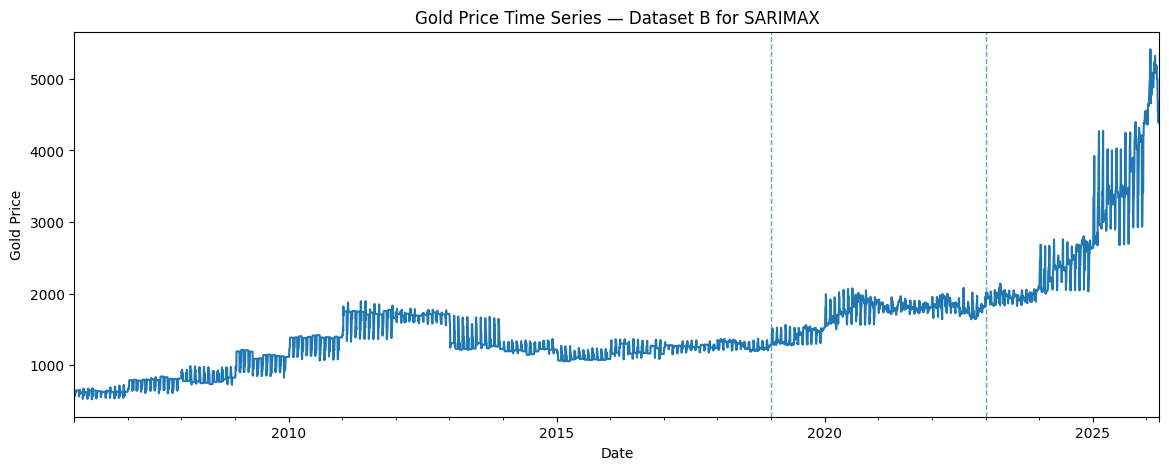


Static multi-step SARIMAX validation leaderboard


,candidate_id,model_name,feature_set,order,order_tuple,forecast_mode,n,mae,mse,rmse,mape,aic,bic,fit_error
0,"lagged_macro_only__SARIMAX(0, 1, 0)",SARIMAX,lagged_macro_only,"(0, 1, 0)","(0, 1, 0)",static_multi_step_validation,1044,293.768887,109418.716890,330.785001,16.415494,37294.669870,37349.821826,None
1,"lagged_macro_only__SARIMAX(1, 1, 0)",SARIMAX,lagged_macro_only,"(1, 1, 0)","(1, 1, 0)",static_multi_step_validation,1044,293.906155,109518.145684,330.935259,16.423168,37277.275489,37338.555440,None
2,"lagged_macro_only__SARIMAX(0, 1, 1)",SARIMAX,lagged_macro_only,"(0, 1, 1)","(0, 1, 1)",static_multi_step_validation,1044,294.219172,109745.572747,331.278693,16.440654,37264.330456,37325.607454,None
3,"lagged_macro_only__SARIMAX(1, 1, 1)",SARIMAX,lagged_macro_only,"(1, 1, 1)","(1, 1, 1)",static_multi_step_validation,1044,308.952356,119947.890425,346.334940,17.282588,36988.149091,37055.553789,None
4,"lagged_macro_plus_trend_month__SARIMAX(1, 1, 1)",SARIMAX,lagged_macro_plus_trend_month,"(1, 1, 1)","(1, 1, 1)",static_multi_step_validation,1044,524.997089,347241.074524,589.271647,29.407292,36985.606662,37077.522160,None
5,"lagged_macro_plus_trend_month__SARIMAX(0, 1, 0)",SARIMAX,lagged_macro_plus_trend_month,"(0, 1, 0)","(0, 1, 0)",static_multi_step_validation,1044,529.346807,352639.903715,593.834913,29.677730,37289.951716,37369.615652,None
6,"lagged_macro_plus_trend_month__SARIMAX(1, 1, 0)",SARIMAX,lagged_macro_plus_trend_month,"(1, 1, 0)","(1, 1, 0)",static_multi_step_validation,1044,529.422177,352737.678187,593.917232,29.682012,37273.851007,37359.642938,None
7,"lagged_macro_plus_trend_month__SARIMAX(0, 1, 1)",SARIMAX,lagged_macro_plus_trend_month,"(0, 1, 1)","(0, 1, 1)",static_multi_step_validation,1044,537.665751,363915.461847,603.254061,30.146069,37261.118518,37346.906316,None



Rolling one-step SARIMAX validation leaderboard


,candidate_id,model_name,feature_set,order,order_tuple,forecast_mode,n,mae,mse,rmse,mape,append_failures,fit_error
0,"lagged_macro_only__SARIMAX(0, 1, 0)",SARIMAX,lagged_macro_only,"(0, 1, 0)","(0, 1, 0)",one_step_rolling_validation,1044,33.921949,4526.997922,67.282969,1.990497,0,None
1,"lagged_macro_only__SARIMAX(0, 1, 1)",SARIMAX,lagged_macro_only,"(0, 1, 1)","(0, 1, 1)",one_step_rolling_validation,1044,34.525961,4527.877517,67.289505,2.029782,0,None
2,"lagged_macro_only__SARIMAX(1, 1, 0)",SARIMAX,lagged_macro_only,"(1, 1, 0)","(1, 1, 0)",one_step_rolling_validation,1044,34.421005,4529.336230,67.300343,2.022905,0,None



✅ Selected SARIMAX candidate by rolling validation RMSE: lagged_macro_only__SARIMAX(0, 1, 0)


,candidate_id,model_name,feature_set,order,order_tuple,forecast_mode,n,mae,mse,rmse,mape,append_failures,fit_error
0,"lagged_macro_only__SARIMAX(0, 1, 0)",SARIMAX,lagged_macro_only,"(0, 1, 0)","(0, 1, 0)",one_step_rolling_validation,1044,33.921949,4526.997922,67.282969,1.990497,0,None



Selected SARIMAX static test diagnostic


,n,mae,mse,rmse,mape,candidate_id,forecast_mode
0,847,887.594875,1.502363e+06,1225.709227,26.221296,"lagged_macro_only__SARIMAX(0, 1, 0)",static_multi_step_test



Selected SARIMAX rolling test performance


,n,mae,mse,rmse,mape,candidate_id,forecast_mode,append_failures
0,847,77.174777,32634.087058,180.649072,2.715454,"lagged_macro_only__SARIMAX(0, 1, 0)",one_step_rolling_test,0


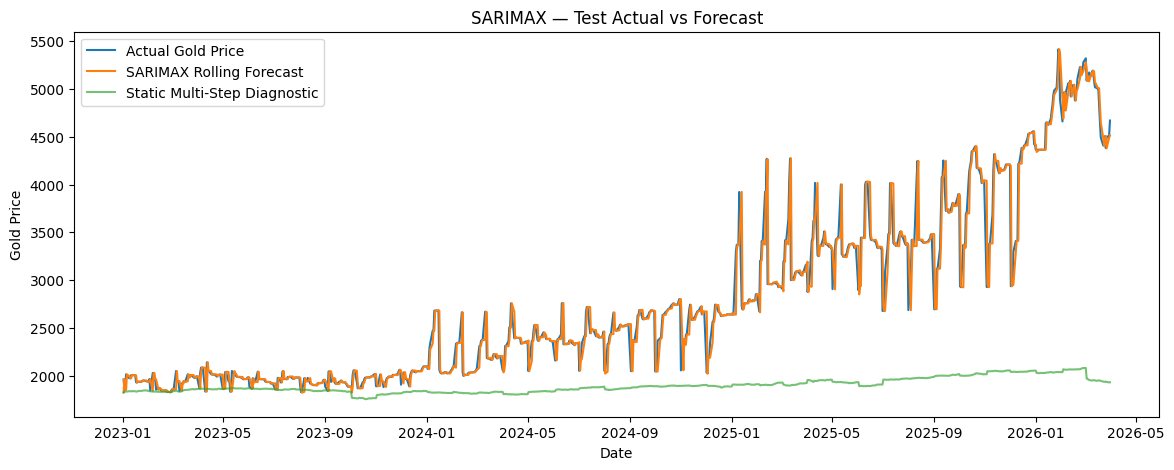

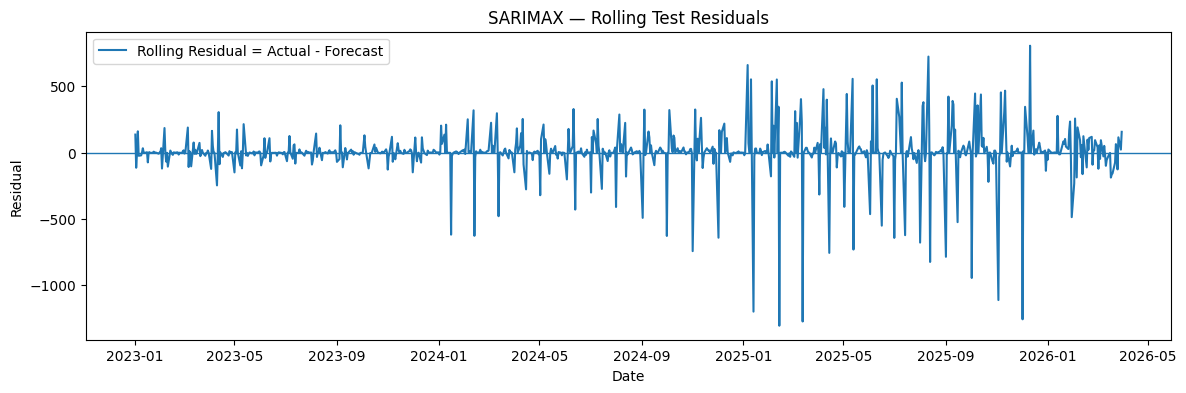

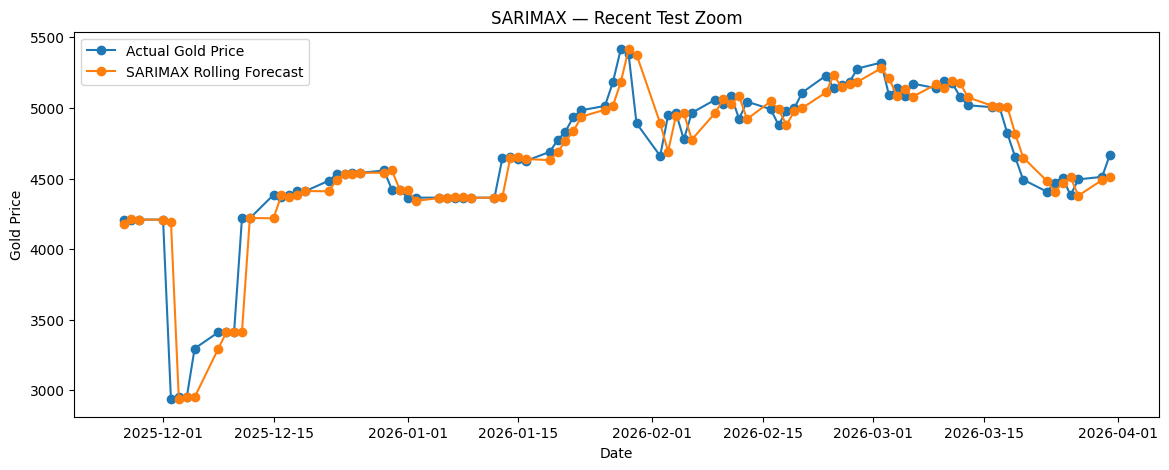

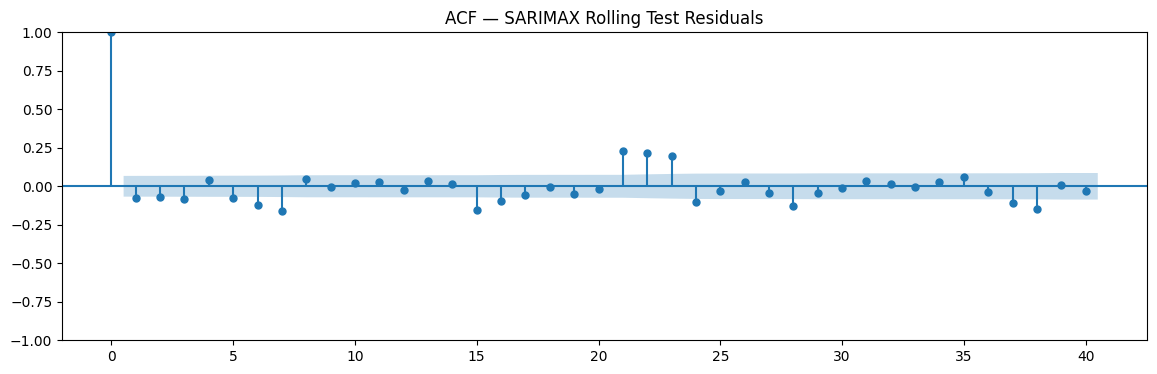

In [5]:
import sys
import json
import math
import glob
import warnings
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    import statsmodels

try:
    import sklearn
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    import sklearn

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics import tsaplots

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 160)





# ======================================================================================
# CELL 4 — MAIN SARIMAX MODELING LOGIC
# ======================================================================================
# Purpose:
# - Static SARIMAX forecasts are diagnostic.
# - One-step rolling SARIMAX forecasts are the primary fair comparison mode.
# - Lagged exogenous variables are used to reduce leakage risk.
# ======================================================================================


def json_safe(value):
    """Convert pandas/numpy objects into JSON-safe Python values."""
    import pandas as pd
    import numpy as np
    import math
    if value is None:
        return None
    if isinstance(value, (pd.Timestamp,)):
        return value.strftime("%Y-%m-%d")
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value
    if isinstance(value, (np.ndarray, list, tuple)):
        return [json_safe(x) for x in value]
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    return value

def write_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    clean_payload = json_safe(payload)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(clean_payload, f, indent=2)
    print(f"✅ Wrote {path}")

def metrics(actual, prediction):
    actual = pd.Series(actual).astype(float)
    prediction = pd.Series(prediction).astype(float)
    aligned = pd.concat([actual.rename("actual"), prediction.rename("prediction")], axis=1).dropna()
    if aligned.empty:
        return {"n": 0, "mae": None, "mse": None, "rmse": None, "mape": None}
    err = aligned["actual"] - aligned["prediction"]
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    denom = aligned["actual"].replace(0, np.nan)
    mape = float((np.abs(err / denom).dropna().mean()) * 100)
    return {"n": int(len(aligned)), "mae": mae, "mse": mse, "rmse": rmse, "mape": mape}

def path_records(df, max_rows=None):
    out = df.copy()
    if max_rows is not None and len(out) > max_rows:
        out = out.tail(max_rows).copy()
    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"]).dt.strftime("%Y-%m-%d")
    return out.replace({np.nan: None}).to_dict(orient="records")

def add_split_lines(ax, validation_start, test_start):
    ax.axvline(pd.Timestamp(validation_start), linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(pd.Timestamp(test_start), linestyle="--", linewidth=1, alpha=0.7)


RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat()

# 1) Plot target first.
fig, ax = plt.subplots(figsize=(14, 5))
plot_df = model_df.set_index("date")
plot_df[TARGET_COL].plot(ax=ax)
ax.set_title("Gold Price Time Series — Dataset B for SARIMAX")
ax.set_xlabel("Date")
ax.set_ylabel("Gold Price")
add_split_lines(ax, VALIDATION_START, TEST_START)
plt.show()

def scale_splits(feature_cols, train_source, validation_source=None, test_source=None):
    scaler = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(train_source[feature_cols]),
        index=train_source["date"],
        columns=feature_cols
    )
    y_train = pd.Series(train_source[TARGET_COL].values, index=train_source["date"], name=TARGET_COL)

    X_validation = None
    y_validation = None
    if validation_source is not None:
        X_validation = pd.DataFrame(
            scaler.transform(validation_source[feature_cols]),
            index=validation_source["date"],
            columns=feature_cols
        )
        y_validation = pd.Series(validation_source[TARGET_COL].values, index=validation_source["date"], name=TARGET_COL)

    X_test = None
    y_test = None
    if test_source is not None:
        X_test = pd.DataFrame(
            scaler.transform(test_source[feature_cols]),
            index=test_source["date"],
            columns=feature_cols
        )
        y_test = pd.Series(test_source[TARGET_COL].values, index=test_source["date"], name=TARGET_COL)

    return scaler, y_train, X_train, y_validation, X_validation, y_test, X_test

def fit_sarimax_model(y_train, X_train, order):
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False, maxiter=120)
    return result

def static_forecast_sarimax(y_train, X_train, y_eval, X_eval, order):
    result = fit_sarimax_model(y_train, X_train, order)
    fc = result.get_forecast(steps=len(y_eval), exog=X_eval)
    pred = pd.Series(fc.predicted_mean.values, index=y_eval.index, name="prediction")
    fitted = pd.Series(result.fittedvalues.values, index=y_train.index, name="fitted")
    return result, fitted, pred

def rolling_forecast_sarimax(y_initial, X_initial, y_eval, X_eval, order, feature_set_name):
    history_y = y_initial.copy()
    history_X = X_initial.copy()
    result = fit_sarimax_model(history_y, history_X, order)

    rows = []
    append_failures = 0

    for date in y_eval.index:
        xrow = X_eval.loc[[date]]
        try:
            pred_value = float(result.get_forecast(steps=1, exog=xrow).predicted_mean.iloc[0])
        except Exception:
            # Conservative fallback: refit if the state object becomes unstable.
            result = fit_sarimax_model(history_y, history_X, order)
            pred_value = float(result.get_forecast(steps=1, exog=xrow).predicted_mean.iloc[0])

        actual_value = float(y_eval.loc[date])
        rows.append({
            "date": date,
            "actual": actual_value,
            "prediction": pred_value,
            "residual": actual_value - pred_value,
            "feature_set": feature_set_name,
            "order": str(order),
        })

        new_y = pd.Series([actual_value], index=[date], name=TARGET_COL)
        history_y = pd.concat([history_y, new_y])
        history_X = pd.concat([history_X, xrow])

        try:
            result = result.append(new_y, exog=xrow, refit=False)
        except Exception:
            append_failures += 1
            if ROLLING_REFIT_ON_APPEND_FAILURE:
                result = fit_sarimax_model(history_y, history_X, order)

    path = pd.DataFrame(rows)
    return path, append_failures

# 2) Static candidate leaderboard across feature sets and orders.
static_validation_rows = []
static_candidate_objects = {}

for feature_set_name, feature_cols in FEATURE_SETS.items():
    if len(feature_cols) == 0:
        continue

    scaler, y_train, X_train, y_val, X_val, _, _ = scale_splits(feature_cols, train_df, validation_df, None)

    for order in SARIMAX_CANDIDATE_ORDERS:
        candidate_id = f"{feature_set_name}__SARIMAX{order}"
        try:
            result, fitted, pred_val = static_forecast_sarimax(y_train, X_train, y_val, X_val, order)
            m = metrics(y_val, pred_val)
            static_validation_rows.append({
                "candidate_id": candidate_id,
                "model_name": "SARIMAX",
                "feature_set": feature_set_name,
                "order": str(order),
                "order_tuple": order,
                "forecast_mode": "static_multi_step_validation",
                **m,
                "aic": float(result.aic) if hasattr(result, "aic") else None,
                "bic": float(result.bic) if hasattr(result, "bic") else None,
                "fit_error": None,
            })
            static_candidate_objects[candidate_id] = {
                "result": result,
                "fitted": fitted,
                "validation_prediction": pred_val,
                "feature_cols": feature_cols,
                "feature_set": feature_set_name,
                "order": order,
            }
        except Exception as e:
            static_validation_rows.append({
                "candidate_id": candidate_id,
                "model_name": "SARIMAX",
                "feature_set": feature_set_name,
                "order": str(order),
                "order_tuple": order,
                "forecast_mode": "static_multi_step_validation",
                "n": 0,
                "mae": None,
                "mse": None,
                "rmse": None,
                "mape": None,
                "aic": None,
                "bic": None,
                "fit_error": str(e),
            })

static_validation_table = pd.DataFrame(static_validation_rows).sort_values("rmse", na_position="last").reset_index(drop=True)
print("\nStatic multi-step SARIMAX validation leaderboard")
display(static_validation_table)

valid_static_candidates = static_validation_table.dropna(subset=["rmse"]).head(MAX_STATIC_CANDIDATES_TO_ROLL).copy()
if valid_static_candidates.empty:
    raise RuntimeError("No SARIMAX static candidates fitted successfully.")

# 3) Rolling validation for top static candidates.
rolling_validation_rows = []
rolling_validation_paths = {}

for _, row in valid_static_candidates.iterrows():
    candidate_id = row["candidate_id"]
    obj = static_candidate_objects[candidate_id]
    feature_cols = obj["feature_cols"]
    order = tuple(obj["order"]) if not isinstance(obj["order"], tuple) else obj["order"]
    feature_set_name = obj["feature_set"]

    scaler, y_train, X_train, y_val, X_val, _, _ = scale_splits(feature_cols, train_df, validation_df, None)

    try:
        path, append_failures = rolling_forecast_sarimax(y_train, X_train, y_val, X_val, order, feature_set_name)
        m = metrics(path["actual"], path["prediction"])
        rolling_validation_rows.append({
            "candidate_id": candidate_id,
            "model_name": "SARIMAX",
            "feature_set": feature_set_name,
            "order": str(order),
            "order_tuple": order,
            "forecast_mode": "one_step_rolling_validation",
            **m,
            "append_failures": int(append_failures),
            "fit_error": None,
        })
        rolling_validation_paths[candidate_id] = path
    except Exception as e:
        rolling_validation_rows.append({
            "candidate_id": candidate_id,
            "model_name": "SARIMAX",
            "feature_set": feature_set_name,
            "order": str(order),
            "order_tuple": order,
            "forecast_mode": "one_step_rolling_validation",
            "n": 0,
            "mae": None,
            "mse": None,
            "rmse": None,
            "mape": None,
            "append_failures": None,
            "fit_error": str(e),
        })

rolling_validation_table = pd.DataFrame(rolling_validation_rows).sort_values("rmse", na_position="last").reset_index(drop=True)
print("\nRolling one-step SARIMAX validation leaderboard")
display(rolling_validation_table)

if rolling_validation_table.dropna(subset=["rmse"]).empty:
    raise RuntimeError("No SARIMAX rolling validation candidates completed successfully.")

selected_row = rolling_validation_table.dropna(subset=["rmse"]).iloc[0].to_dict()
SELECTED_CANDIDATE_ID = selected_row["candidate_id"]
SELECTED_FEATURE_SET = selected_row["feature_set"]
SELECTED_ORDER = selected_row["order_tuple"]
if not isinstance(SELECTED_ORDER, tuple):
    SELECTED_ORDER = tuple(selected_row["order_tuple"])

print("\n✅ Selected SARIMAX candidate by rolling validation RMSE:", SELECTED_CANDIDATE_ID)
display(pd.DataFrame([selected_row]))

# 4) Final test evaluation. Refit scaler and SARIMAX on train + validation, then roll through test.
train_validation_df = pd.concat([train_df, validation_df], axis=0).sort_values("date").reset_index(drop=True)
selected_feature_cols = FEATURE_SETS[SELECTED_FEATURE_SET]

scaler, y_trainval, X_trainval, _, _, y_test, X_test = scale_splits(selected_feature_cols, train_validation_df, None, test_df)

# Static test diagnostic.
try:
    static_test_result, static_fitted_trainval, static_test_pred = static_forecast_sarimax(
        y_trainval, X_trainval, y_test, X_test, SELECTED_ORDER
    )
    static_test_metrics = metrics(y_test, static_test_pred)
except Exception as e:
    print("⚠️ Static test diagnostic failed:", e)
    static_test_result = None
    static_fitted_trainval = pd.Series(dtype=float)
    static_test_pred = pd.Series(index=y_test.index, dtype=float)
    static_test_metrics = {"n": 0, "mae": None, "mse": None, "rmse": None, "mape": None, "fit_error": str(e)}

# Rolling test.
selected_test_path, selected_append_failures = rolling_forecast_sarimax(
    y_trainval, X_trainval, y_test, X_test, SELECTED_ORDER, SELECTED_FEATURE_SET
)
rolling_test_metrics = metrics(selected_test_path["actual"], selected_test_path["prediction"])

print("\nSelected SARIMAX static test diagnostic")
display(pd.DataFrame([{**static_test_metrics, "candidate_id": SELECTED_CANDIDATE_ID, "forecast_mode": "static_multi_step_test"}]))

print("\nSelected SARIMAX rolling test performance")
display(pd.DataFrame([{**rolling_test_metrics, "candidate_id": SELECTED_CANDIDATE_ID, "forecast_mode": "one_step_rolling_test", "append_failures": selected_append_failures}]))

# 5) Build forecast path.
forecast_path = pd.DataFrame({
    "date": y_test.index,
    "actual": y_test.values,
    "static_forecast": static_test_pred.reindex(y_test.index).values,
})
rolling_map = selected_test_path.set_index("date")["prediction"]
forecast_path["rolling_forecast"] = forecast_path["date"].map(rolling_map)
forecast_path["residual"] = forecast_path["actual"] - forecast_path["rolling_forecast"]
forecast_path["abs_error"] = forecast_path["residual"].abs()
forecast_path["forecast_mode_default"] = "one_step_rolling"

# 6) Coefficients and diagnostics.
coefficient_table = []
if static_test_result is not None:
    try:
        params = static_test_result.params
        pvalues = static_test_result.pvalues
        for name in params.index:
            coefficient_table.append({
                "term": str(name),
                "coefficient": float(params.loc[name]),
                "p_value": float(pvalues.loc[name]) if name in pvalues.index else None,
            })
    except Exception:
        coefficient_table = []

try:
    lb = acorr_ljungbox(forecast_path["residual"].dropna(), lags=[10, 20], return_df=True)
    ljung_box_records = lb.reset_index().rename(columns={"index": "lag"}).to_dict(orient="records")
except Exception as e:
    ljung_box_records = [{"error": str(e)}]

# 7) Professor-style charts.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(forecast_path["date"], forecast_path["actual"], label="Actual Gold Price")
ax.plot(forecast_path["date"], forecast_path["rolling_forecast"], label="SARIMAX Rolling Forecast")
ax.plot(forecast_path["date"], forecast_path["static_forecast"], label="Static Multi-Step Diagnostic", alpha=0.65)
ax.set_title("SARIMAX — Test Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Gold Price")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forecast_path["date"], forecast_path["residual"], label="Rolling Residual = Actual - Forecast")
ax.axhline(0, linewidth=1)
ax.set_title("SARIMAX — Rolling Test Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend()
plt.show()

zoom_df = forecast_path.tail(90)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom_df["date"], zoom_df["actual"], marker="o", linestyle="-", label="Actual Gold Price")
ax.plot(zoom_df["date"], zoom_df["rolling_forecast"], marker="o", linestyle="-", label="SARIMAX Rolling Forecast")
ax.set_title("SARIMAX — Recent Test Zoom")
ax.set_xlabel("Date")
ax.set_ylabel("Gold Price")
ax.legend()
plt.show()

try:
    fig, ax = plt.subplots(figsize=(14, 4))
    tsaplots.plot_acf(forecast_path["residual"].dropna(), lags=40, ax=ax)
    ax.set_title("ACF — SARIMAX Rolling Test Residuals")
    plt.show()
except Exception as e:
    print("ACF plot skipped:", e)

# Objects used by Cell 5.
sarimax_summary = {
    "notebook": "08_sarimax_forecasting.ipynb",
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "project_identity": "Gold Nexus Alpha professor-style forecasting platform",
    "dataset": {
        "name": "Dataset B — Core Multivariate",
        "target": TARGET_COL,
        "start": CORE_MULTIVARIATE_START,
        "end": CORE_MULTIVARIATE_END,
        "train": {"start": TRAIN_START, "end": TRAIN_END, "rows": len(train_df)},
        "validation": {"start": VALIDATION_START, "end": VALIDATION_END, "rows": len(validation_df)},
        "test": {"start": TEST_START, "end": TEST_END, "rows": len(test_df)},
    },
    "excluded_variables": EXCLUDED_FROM_MAIN_MODEL,
    "exogenous_factor_policy": "Uses lagged exogenous variables to avoid same-day information dependency.",
    "selection_rule": "Top static candidates are rolled through validation; final SARIMAX candidate selected by rolling validation RMSE.",
    "selected_model": {
        "candidate_id": SELECTED_CANDIDATE_ID,
        "order": str(SELECTED_ORDER),
        "feature_set": SELECTED_FEATURE_SET,
        "features": selected_feature_cols,
        "validation_metrics": selected_row,
        "test_metrics_rolling": rolling_test_metrics,
        "test_metrics_static_diagnostic": static_test_metrics,
        "append_failures_test": int(selected_append_failures),
    },
    "static_validation_leaderboard": static_validation_table.to_dict(orient="records"),
    "rolling_validation_leaderboard": rolling_validation_table.to_dict(orient="records"),
    "coefficient_table": coefficient_table,
    "ljung_box": ljung_box_records,
    "interpretation_notes": [
        "Static SARIMAX forecasts are retained as diagnostics because long multi-step forecasts can flatten or lag during regime shifts.",
        "The default frontend chart should use the one-step rolling forecast.",
        "Exogenous variables are lagged by one row/day to reduce leakage risk."
    ],
}

sarimax_forecast_path_df = forecast_path.copy()

In [14]:
# ======================================================================================
# CELL 5 — ROBUST ARTIFACT EXPORT
# ======================================================================================
# Purpose:
# - Export Notebook 08 SARIMAX JSON artifacts.
# - Recreate output folders even if this cell is run by itself after modeling.
# - Verify every expected artifact exists before Cell 6 pushes to GitHub.
# ======================================================================================

import json
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np

# --------------------------------------------------------------------------------------
# 1) Rebuild project/artifact paths safely
# --------------------------------------------------------------------------------------
REPO_NAME = globals().get("REPO_NAME", "nyit-gold-intelligence-2026")
PROJECT_DIR = Path(globals().get("PROJECT_DIR", f"/content/{REPO_NAME}"))

if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"PROJECT_DIR does not exist: {PROJECT_DIR}. "
        "Run Cell 1 first so the repo is cloned. You do NOT need to rerun modeling if variables are still in memory."
    )

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
MODELS_ARTIFACTS_DIR = ARTIFACTS_DIR / "models"
PAGES_ARTIFACTS_DIR = ARTIFACTS_DIR / "pages"

MODELS_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PAGES_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("📁 PROJECT_DIR:", PROJECT_DIR)
print("📁 MODELS_ARTIFACTS_DIR:", MODELS_ARTIFACTS_DIR)
print("📁 PAGES_ARTIFACTS_DIR:", PAGES_ARTIFACTS_DIR)

# --------------------------------------------------------------------------------------
# 2) JSON-safe helpers
# --------------------------------------------------------------------------------------
def to_json_safe(obj):
    """Convert numpy/pandas objects into JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {str(k): to_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if np.isnan(obj) or np.isinf(obj):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return to_json_safe(obj.tolist())
    if isinstance(obj, (pd.Timestamp,)):
        return obj.strftime("%Y-%m-%d")
    if pd.isna(obj) if not isinstance(obj, (list, dict, tuple, np.ndarray)) else False:
        return None
    return obj

def write_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_json_safe(payload), f, indent=2, ensure_ascii=False)
    print(f"✅ Wrote {path} ({path.stat().st_size:,} bytes)")

def path_records(df):
    """Create compact records for forecast path JSON."""
    out = df.copy()
    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"]).dt.strftime("%Y-%m-%d")
    return to_json_safe(out.to_dict(orient="records"))

# --------------------------------------------------------------------------------------
# 3) Verify modeling variables exist
# --------------------------------------------------------------------------------------
required_vars = [
    "sarimax_summary",
    "sarimax_forecast_path_df",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Cell 5 cannot export because these variables are missing: "
        + ", ".join(missing_vars)
        + "\nThis means the modeling cell was not run in this active Colab session. "
        "If the runtime reset, you must rerun the modeling cell. If the model just finished and variables exist, run Cell 5 again."
    )

# Defensive copy
sarimax_summary = to_json_safe(sarimax_summary)
forecast_df = sarimax_forecast_path_df.copy()

# --------------------------------------------------------------------------------------
# 4) Write model artifacts
# --------------------------------------------------------------------------------------
results_path = MODELS_ARTIFACTS_DIR / "sarimax_results.json"
diagnostics_path = MODELS_ARTIFACTS_DIR / "sarimax_diagnostics.json"
forecast_path_json = MODELS_ARTIFACTS_DIR / "sarimax_forecast_path.json"
page_path = PAGES_ARTIFACTS_DIR / "page_sarimax.json"

write_json(results_path, sarimax_summary)

write_json(diagnostics_path, {
    "model_name": "SARIMAX",
    "selected_candidate_id": sarimax_summary.get("selected_model", {}).get("candidate_id"),
    "coefficient_table": sarimax_summary.get("coefficient_table", []),
    "ljung_box": sarimax_summary.get("ljung_box", []),
    "static_validation_leaderboard": sarimax_summary.get("static_validation_leaderboard", []),
    "rolling_validation_leaderboard": sarimax_summary.get("rolling_validation_leaderboard", []),
})

write_json(forecast_path_json, {
    "model_name": "SARIMAX",
    "selected_candidate_id": sarimax_summary.get("selected_model", {}).get("candidate_id"),
    "forecast_mode_default": "one_step_rolling",
    "static_forecast_is_diagnostic": True,
    "records": path_records(forecast_df),
})

page_payload = {
    "page_title": "SARIMAX Forecast",
    "page_subtitle": "Classical ARIMA model with selected lagged exogenous gold drivers and rolling evaluation.",
    "artifact_type": "model_page",
    "model_family": "SARIMAX",
    "default_chart_mode": "one_step_rolling",
    "dataset_window": sarimax_summary.get("dataset", {}),
    "selected_model": sarimax_summary.get("selected_model", {}),
    "leaderboards": {
        "static_validation": sarimax_summary.get("static_validation_leaderboard", []),
        "rolling_validation": sarimax_summary.get("rolling_validation_leaderboard", []),
    },
    "charts": [
        {
            "chart_id": "actual_vs_rolling_forecast",
            "title": "Actual Gold Price vs Rolling SARIMAX Forecast",
            "source_artifact": "artifacts/models/sarimax_forecast_path.json",
            "x": "date",
            "y_actual": "actual",
            "y_forecast": "rolling_forecast"
        },
        {
            "chart_id": "static_forecast_diagnostic",
            "title": "Static Multi-Step Forecast Diagnostic",
            "source_artifact": "artifacts/models/sarimax_forecast_path.json",
            "x": "date",
            "y_actual": "actual",
            "y_forecast": "static_forecast"
        },
        {
            "chart_id": "rolling_residuals",
            "title": "Rolling Forecast Residuals",
            "source_artifact": "artifacts/models/sarimax_forecast_path.json",
            "x": "date",
            "y": "residual"
        }
    ],
    "limitations": sarimax_summary.get("interpretation_notes", []),
    "json_first_rule": "Frontend should read all SARIMAX claims, metrics, and selected-model labels from this artifact.",
    "export_timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"),
}

write_json(page_path, page_payload)

# --------------------------------------------------------------------------------------
# 5) Final verification before push cell
# --------------------------------------------------------------------------------------
expected_files = [results_path, diagnostics_path, forecast_path_json, page_path]
missing_files = [str(p) for p in expected_files if not p.exists()]
if missing_files:
    raise FileNotFoundError("Export failed. Missing files:\n" + "\n".join(missing_files))

print("\n✅ Notebook 08 SARIMAX artifact export complete.")
print("Run Cell 6 next to push these files.")
for p in expected_files:
    print(f" - {p.relative_to(PROJECT_DIR)} | {p.stat().st_size:,} bytes")


✅ Wrote /content/nyit-gold-intelligence-2026/artifacts/models/sarimax_results.json
✅ Wrote /content/nyit-gold-intelligence-2026/artifacts/models/sarimax_diagnostics.json
✅ Wrote /content/nyit-gold-intelligence-2026/artifacts/models/sarimax_forecast_path.json
✅ Wrote /content/nyit-gold-intelligence-2026/artifacts/pages/page_sarimax.json
✅ Notebook 08 v2 exports complete
/content/nyit-gold-intelligence-2026/artifacts/models/sarimax_results.json
/content/nyit-gold-intelligence-2026/artifacts/models/sarimax_diagnostics.json
/content/nyit-gold-intelligence-2026/artifacts/models/sarimax_forecast_path.json
/content/nyit-gold-intelligence-2026/artifacts/pages/page_sarimax.json


In [15]:
# ======================================================================================
# CELL 6 — ROBUST GITHUB PUSH
# ======================================================================================
# Purpose:
# - Push already-created Notebook 08 SARIMAX artifacts to GitHub.
# - Does NOT rerun SARIMAX modeling.
# ======================================================================================

import os
import subprocess
from pathlib import Path
from datetime import datetime, timezone

try:
    from google.colab import userdata
except Exception:
    userdata = None

REPO_OWNER = globals().get("REPO_OWNER", "rathee000001")
REPO_NAME  = globals().get("REPO_NAME", "nyit-gold-intelligence-2026")
BRANCH     = globals().get("BRANCH", "main")
PROJECT_DIR = Path(globals().get("PROJECT_DIR", f"/content/{REPO_NAME}"))

def run_cmd(cmd, cwd=None, allow_fail=False, safe_cmd=None):
    shown = safe_cmd if safe_cmd is not None else cmd
    if isinstance(shown, (list, tuple)):
        shown = " ".join(str(x) for x in shown)
    print(f"\n>> {shown}")
    p = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if p.stdout:
        print(p.stdout)
    if p.stderr:
        print(p.stderr)
    if p.returncode != 0 and not allow_fail:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {shown}")
    return p

GITHUB_TOKEN = globals().get("GITHUB_TOKEN", None)
if not GITHUB_TOKEN and userdata is not None:
    try:
        GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
    except Exception:
        GITHUB_TOKEN = None
if not GITHUB_TOKEN:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"PROJECT_DIR does not exist: {PROJECT_DIR}. Run Cell 1 first.")

files_to_add = [
    "artifacts/models/sarimax_results.json",
    "artifacts/models/sarimax_diagnostics.json",
    "artifacts/models/sarimax_forecast_path.json",
    "artifacts/pages/page_sarimax.json",
]

missing = [f for f in files_to_add if not (PROJECT_DIR / f).exists()]
if missing:
    print("❌ Missing expected SARIMAX artifact files:")
    for f in missing:
        print(" -", PROJECT_DIR / f)
    raise FileNotFoundError("Run the corrected Cell 5 first, then rerun this Cell 6.")

run_cmd(["git", "config", "user.email", "colab-artifact-bot@gold-nexus-alpha.local"], cwd=str(PROJECT_DIR))
run_cmd(["git", "config", "user.name", "Gold Nexus Alpha Colab"], cwd=str(PROJECT_DIR))

if GITHUB_TOKEN:
    auth_url = f"https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git"
    safe_url = f"https://***@github.com/{REPO_OWNER}/{REPO_NAME}.git"
    run_cmd(
        ["git", "remote", "set-url", "origin", auth_url],
        cwd=str(PROJECT_DIR),
        safe_cmd=["git", "remote", "set-url", "origin", safe_url]
    )
else:
    print("⚠️ GITHUB_TOKEN not found. Push may fail.")

print("📌 Artifact files detected:")
for f in files_to_add:
    p = PROJECT_DIR / f
    print(f" - {f} | {p.stat().st_size:,} bytes")

print("\n📌 Git status before add:")
run_cmd(["git", "status", "--short"], cwd=str(PROJECT_DIR), allow_fail=True)

run_cmd(["git", "add", "-f"] + files_to_add, cwd=str(PROJECT_DIR))

status_after_add = run_cmd(["git", "status", "--porcelain"], cwd=str(PROJECT_DIR), allow_fail=True).stdout.strip()

if not status_after_add:
    print("✅ No artifact changes detected. Nothing to commit or push.")
else:
    print("📌 Files staged/changed:")
    print(status_after_add)

    commit_message = f"Update Notebook 08 SARIMAX artifacts {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}"
    commit_result = run_cmd(["git", "commit", "-m", commit_message], cwd=str(PROJECT_DIR), allow_fail=True)

    if commit_result.returncode != 0:
        latest_status = run_cmd(["git", "status", "--porcelain"], cwd=str(PROJECT_DIR), allow_fail=True).stdout.strip()
        if not latest_status:
            print("✅ Nothing to commit after staging.")
        else:
            raise RuntimeError("Commit failed even though there are changes. See Git output above.")

    pull_result = run_cmd(["git", "pull", "--rebase", "--autostash", "origin", BRANCH], cwd=str(PROJECT_DIR), allow_fail=True)
    if pull_result.returncode != 0:
        run_cmd(["git", "rebase", "--abort"], cwd=str(PROJECT_DIR), allow_fail=True)
        run_cmd(["git", "status"], cwd=str(PROJECT_DIR), allow_fail=True)
        raise RuntimeError("Pull/rebase failed. Send me the exact Git output.")

    push_result = run_cmd(["git", "push", "origin", BRANCH], cwd=str(PROJECT_DIR), allow_fail=True)
    if push_result.returncode != 0:
        print("⚠️ First push failed. Retrying after pull/rebase once...")
        run_cmd(["git", "pull", "--rebase", "--autostash", "origin", BRANCH], cwd=str(PROJECT_DIR), allow_fail=True)
        push_result_2 = run_cmd(["git", "push", "origin", BRANCH], cwd=str(PROJECT_DIR), allow_fail=True)
        if push_result_2.returncode != 0:
            raise RuntimeError("Git push still failed. Check token permissions, branch protection, or conflict output.")

    print("✅ GitHub push complete.")

print("✅ Notebook 08 SARIMAX artifact push cell complete.")


📌 Git status before add:
>> git status --short
>> git add artifacts/models/sarimax_results.json artifacts/models/sarimax_diagnostics.json artifacts/models/sarimax_forecast_path.json artifacts/pages/page_sarimax.json
>> git status --porcelain
✅ No changes to commit. Artifacts already match repository.
✅ Notebook 08 v2 professor-style SARIMAX revision complete.
